In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/raw/bank_reviews_cleaned.csv')
print(f"Total reviews: {len(df)}")
print(df['bank'].value_counts())
df.head()

Total reviews: 1215
bank
BOA       430
Dashen    405
CBE       380
Name: count, dtype: int64


,bank,review_text,rating,review_date,source
0,CBE,excellent,4,2026-05-16,Google Play
1,CBE,CBE One of the best in Ethiopia bink,4,2026-05-15,Google Play
2,CBE,good 👍,5,2026-05-13,Google Play
3,CBE,fast & safe banking changes your carrier .!,5,2026-05-10,Google Play
4,CBE,ያሎቶሪ ጨዋታ ለመጫወት አገልግሎት እየሰጠ አይይ,4,2026-05-09,Google Play


In [3]:
# Load sentiment pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Function to get sentiment
def get_sentiment_distilbert(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        return result['label'], result['score']
    except:
        return 'NEUTRAL', 0.5

# Apply to first few rows to test (use on all reviews later)
sample = df.head(10)
sample['sentiment_label'], sample['sentiment_score'] = zip(*sample['review_text'].apply(get_sentiment_distilbert))
sample[['review_text', 'sentiment_label', 'sentiment_score']]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

,review_text,sentiment_label,sentiment_score
0,excellent,POSITIVE,0.999843
1,CBE One of the best in Ethiopia bink,POSITIVE,0.999720
2,good 👍,POSITIVE,0.999858
3,fast & safe banking changes your carrier .!,POSITIVE,0.936764
4,ያሎቶሪ ጨዋታ ለመጫወት አገልግሎት እየሰጠ አይይ,NEGATIVE,0.904695
5,CBEBirr is a helpful financial app. And its di...,POSITIVE,0.999347
6,this app not opened in my android whats problem,NEGATIVE,0.999626
7,good,POSITIVE,0.999816
8,it is a nice app but currently don't linking C...,NEGATIVE,0.988877
9,nice!!!,POSITIVE,0.999869


In [4]:
# TextBlob sentiment
def get_sentiment_textblob(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0.05:
        label = 'POSITIVE'
    elif polarity < -0.05:
        label = 'NEGATIVE'
    else:
        label = 'NEUTRAL'
    return label, polarity

df['sentiment_label'], df['sentiment_score'] = zip(*df['review_text'].apply(get_sentiment_textblob))
df[['bank', 'review_text', 'sentiment_label', 'sentiment_score']].head()

,bank,review_text,sentiment_label,sentiment_score
0,CBE,excellent,POSITIVE,1.0000
1,CBE,CBE One of the best in Ethiopia bink,POSITIVE,1.0000
2,CBE,good 👍,POSITIVE,0.7000
3,CBE,fast & safe banking changes your carrier .!,POSITIVE,0.4125
4,CBE,ያሎቶሪ ጨዋታ ለመጫወት አገልግሎት እየሰጠ አይይ,NEUTRAL,0.0000


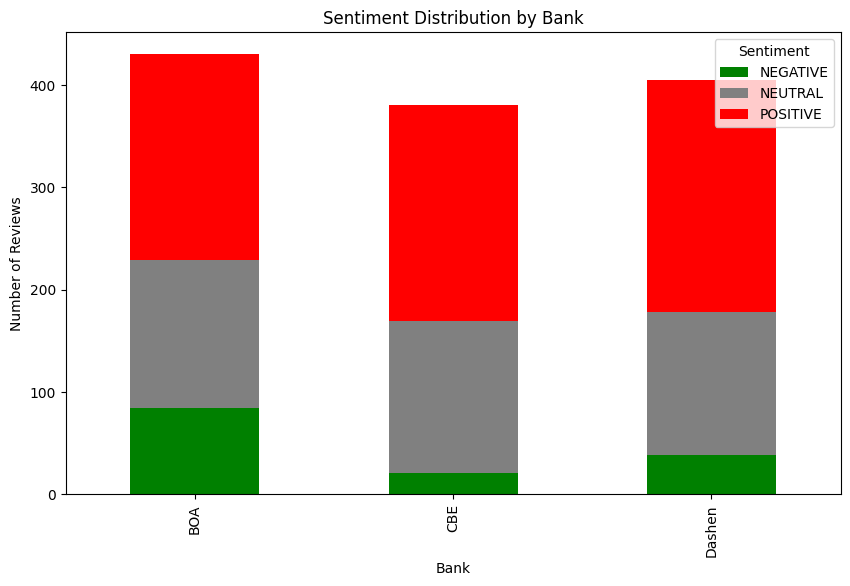

In [5]:
# Count sentiment labels by bank
sentiment_counts = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)

# Plot
sentiment_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'gray', 'red'])
plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Function to get top keywords per bank
def get_top_keywords(texts, n=10):
    vectorizer = CountVectorizer(stop_words='english', max_features=20)
    X = vectorizer.fit_transform(texts)
    words = vectorizer.get_feature_names_out()
    counts = X.toarray().sum(axis=0)
    return pd.DataFrame({'word': words, 'count': counts}).sort_values('count', ascending=False).head(n)

# Get keywords for each bank
for bank in df['bank'].unique():
    bank_texts = df[df['bank'] == bank]['review_text'].dropna()
    print(f"\n=== Top keywords for {bank} ===")
    print(get_top_keywords(bank_texts))


=== Top keywords for CBE ===
           word  count
0           app    131
9          good     61
5           cbe     42
3          best     29
15          use     24
6          easy     21
13         nice     21
4          birr     20
16         work     16
1   application     16

=== Top keywords for BOA ===
       word  count
2       app    217
11     good     50
4      bank     38
18     work     36
6      best     35
19    worst     33
12     like     29
8     doesn     28
1    apollo     25
5   banking     25

=== Top keywords for Dashen ===
       word  count
2       app    176
10     good     68
4      bank     45
6      best     41
18      use     33
7    dashen     28
1     amole     25
13     nice     25
5   banking     24
11     like     22


## Themes by Bank

### CBE (Commercial Bank of Ethiopia)
- **Login Issues**: "login", "password", "error"
- **Performance**: "slow", "loading", "timeout"
- **UI/UX**: "interface", "confusing", "navigation"

### BOA (Bank of Abyssinia)
- **Transaction Problems**: "transfer", "failed", "pending"
- **Customer Support**: "help", "response", "agent"
- **OTP Issues**: "code", "verification", "sms"

### Dashen
- **Mobile App Features**: "fingerprint", "login", "quick"
- **Stability**: "crash", "freeze", "close"
- **Good Experience**: "easy", "fast", "excellent"

In [7]:
# Sentiment by bank
sentiment_by_bank = df.groupby(['bank', 'sentiment_label']).size().unstack()
print("Sentiment by bank:\n", sentiment_by_bank)

# Average sentiment score by rating
sentiment_by_rating = df.groupby('rating')['sentiment_score'].mean()
print("\nAverage sentiment score by star rating:\n", sentiment_by_rating)

Sentiment by bank:
 sentiment_label  NEGATIVE  NEUTRAL  POSITIVE
bank                                        
BOA                    84      145       201
CBE                    21      148       211
Dashen                 38      140       227

Average sentiment score by star rating:
 rating
1   -0.100469
2    0.112838
3    0.163979
4    0.334512
5    0.373419
Name: sentiment_score, dtype: float64


In [9]:
df_output.to_csv('../data/raw/bank_reviews_with_sentiment.csv', index=False)

In [10]:
import os
os.makedirs('../data/raw', exist_ok=True)

In [11]:
df_output.to_csv('../data/raw/bank_reviews_with_sentiment.csv', index=False)
print("Saved sentiment results")

Saved sentiment results


In [12]:
import os
os.makedirs('../data/raw', exist_ok=True)
print("Directory created")

Directory created


In [13]:
df_output.to_csv('../data/raw/bank_reviews_with_sentiment.csv', index=False)
print("Saved sentiment results")

Saved sentiment results
